# Notebook 01 — Navier-Stokes Solver Demo
### Lid-Driven Cavity Flow: Theory, Numerics, and Validation

This notebook demonstrates the 2-D incompressible Navier-Stokes solver implemented in `solver/ns_solver.py`. 
It covers the governing equations, numerical method, boundary conditions, and benchmark validation for the 
**single lid-driven cavity** — the canonical test case for incompressible flow solvers.

---
| Parameter | Value | Notes |
|---|---|---|
| Grid | 64 × 64 | Collocated finite-difference |
| Method | Chorin projection | Fractional-step |
| Advection | First-order upwind | Stable, dissipative |
| Pressure solver | SOR (ω=1.7) | Gauss-Seidel variant |
| Re range | 100 – 3200 | Laminar to weakly turbulent |
| Channels saved | u, v, p, ω | Per snapshot |


## 0. Setup

In [24]:
import sys, os
import glob
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from solver.ns_solver import (NSconfig, apply_bc, step, stable_dt, vorticity,energy_spectrum, is_converged, ghia_u, ghia_v)

## 1. Governing Equations

### 1.1 Incompressible Navier-Stokes Equations

The motion of a viscous, incompressible Newtonian fluid is governed by the **Navier-Stokes equations**. 
In two dimensions, with velocity field **u** = (u, v), pressure p, kinematic viscosity ν, and fluid density ρ:

**Momentum equation:**
$$\frac{\partial \mathbf{u}}{\partial t} + (\mathbf{u} \cdot \nabla)\mathbf{u} = -\frac{1}{\rho}\nabla p + \nu \nabla^2 \mathbf{u}$$

**Continuity equation (incompressibility constraint):**
$$\nabla \cdot \mathbf{u} = \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0$$

The four terms in the momentum equation represent:
1. **Unsteady term** $\partial\mathbf{u}/\partial t$ — rate of change of momentum
2. **Advection** $(\mathbf{u}\cdot\nabla)\mathbf{u}$ — momentum transport by the flow itself (nonlinear)
3. **Pressure gradient** $-\nabla p/\rho$ — pressure-driven acceleration
4. **Viscous diffusion** $\nu\nabla^2\mathbf{u}$ — molecular momentum diffusion

### 1.2 Non-Dimensionalisation

We non-dimensionalise using the lid velocity $U = 1$ m/s and cavity side length $L = 1$ m. 
The single dimensionless parameter governing the flow is the **Reynolds number**:

$$Re = \frac{UL}{\nu}$$

This represents the ratio of inertial to viscous forces. Setting $U = L = \rho = 1$, the kinematic viscosity becomes simply $\nu = 1/Re$. 
In this non-dimensional form, the governing equations are identical but the single parameter Re controls all flow behaviour:

| Re | Flow regime | Physical example |
|---|---|---|
| 100 | Steady laminar | Glycerin flow |
| 400 | Steady, secondary vortices appear | Viscous oil |
| 1000 | Steady (marginally) | Water in a slow channel |
| 3200 | Weakly unsteady, transitional | Water at moderate speed |

### 1.3 Vorticity

The scalar vorticity $\omega$ measures local rotation rate:

$$\omega = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y}$$

Positive $\omega$ indicates counter-clockwise rotation; negative indicates clockwise. 
For the lid-driven cavity with the lid moving rightward, the primary vortex rotates **clockwise**, 
giving $\omega < 0$ in the bulk and a strongly negative mean vorticity across the domain.

## 2. Numerical Method — Chorin Projection

### 2.1 The Pressure-Velocity Coupling Problem

The incompressible Navier-Stokes equations present a fundamental numerical difficulty: the pressure field 
is not governed by a time-evolution equation. Instead, pressure acts as a Lagrange multiplier that 
enforces the constraint $\nabla\cdot\mathbf{u} = 0$ at all times. Solving the coupled pressure-velocity 
system simultaneously is computationally expensive.

### 2.2 The Fractional-Step Method (Chorin 1968)

Chorin's projection method decouples pressure from velocity by splitting each time step into three stages:

**Stage 1 — Intermediate velocity** (advection + diffusion only, no pressure):
$$\frac{\mathbf{u}^* - \mathbf{u}^n}{\Delta t} = -(\mathbf{u}^n\cdot\nabla)\mathbf{u}^n + \nu\nabla^2\mathbf{u}^n$$

**Stage 2 — Pressure Poisson equation** (enforce divergence-free):
$$\nabla^2 p^{n+1} = \frac{\rho}{\Delta t}\nabla\cdot\mathbf{u}^*$$

**Stage 3 — Projection** (correct velocity using pressure gradient):
$$\mathbf{u}^{n+1} = \mathbf{u}^* - \frac{\Delta t}{\rho}\nabla p^{n+1}$$

The projection step is geometrically a Helmholtz decomposition: any vector field can be uniquely 
decomposed into a divergence-free part and an irrotational part. The pressure gradient is the irrotational 
component and subtracting it yields the divergence-free velocity.

### 2.3 Spatial Discretisation

**Grid:** We use a collocated grid where all variables (u, v, p) are defined at cell centres. 
The domain $[0,L]^2$ is discretised into $N\times N = 64\times 64$ cells with spacing $\Delta x = \Delta y = L/N$.

**Advection — first-order upwind:**
$$\left.u\frac{\partial u}{\partial x}\right|_i \approx u_i \cdot \begin{cases} (u_i - u_{i-1})/\Delta x & \text{if } u_i > 0 \\ (u_{i+1} - u_i)/\Delta x & \text{if } u_i < 0 \end{cases}$$
Upwind differencing is numerically stable (introduces dissipation rather than dispersion) at the cost of 
first-order spatial accuracy.

**Diffusion — second-order central difference:**
$$\nu\frac{\partial^2 u}{\partial x^2}\bigg|_i \approx \nu\frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2}$$

### 2.4 Time Step Stability Conditions

Two stability constraints must both be satisfied simultaneously:

**CFL condition** (convective stability):
$$\Delta t < \frac{\alpha \cdot \Delta x}{|\mathbf{u}|_{\max}}$$

**Viscous stability condition:**
$$\Delta t < \frac{\alpha \cdot \Delta x^2}{4\nu}$$

where $\alpha = 0.2$ is a safety factor. At Re=3200, the viscous condition is more restrictive, 
giving $\Delta t \approx 5\times10^{-5}$ s on a 64×64 grid.

## 3. Pressure Solver — Successive Over-Relaxation

The pressure Poisson equation $\nabla^2 p = f$ on a square domain with Neumann boundary conditions 
is solved iteratively using **Successive Over-Relaxation (SOR)**, a stationary iterative method.

### 3.1 Discrete Laplacian

The discrete five-point Laplacian at interior node $(i,j)$:

$$\nabla^2 p \approx \frac{p_{i+1,j} + p_{i-1,j} + p_{i,j+1} + p_{i,j-1} - 4p_{i,j}}{\Delta x^2}$$

### 3.2 SOR Update Rule

The Gauss-Seidel residual at each point is:
$$r_{i,j} = \frac{p_{i+1,j} + p_{i-1,j} + p_{i,j+1} + p_{i,j-1}}{4} - p_{i,j} - \frac{\Delta x^2}{4}f_{i,j}$$

The SOR update accelerates convergence by over-correcting:
$$p_{i,j}^{\text{new}} = p_{i,j} + \omega_{\text{SOR}} \cdot r_{i,j}$$

The optimal relaxation parameter for a square domain is $\omega_{\text{SOR}} \approx 2/(1 + \sin(\pi/N))$, 
which gives $\omega_{\text{SOR}} \approx 1.7$ for $N=64$. Values above the optimum cause divergence; 
values below slow convergence. Convergence is declared when $|\nabla\cdot\mathbf{u}|_{\max} < 10^{-6}$.

### 3.3 Pressure Boundary Conditions

The Neumann condition $\partial p/\partial n = 0$ is applied at all walls (no pressure flux through solid boundaries). 
Mean pressure is subtracted each iteration to ensure uniqueness (the Poisson equation with Neumann BCs has a 
solution only up to an additive constant).

## 4. Lid-Driven Cavity — Physical Description

### 4.1 Problem Definition

The lid-driven cavity consists of a square domain $[0,L]^2$ filled with viscous fluid. 
The **top wall (y=L) moves rightward** at velocity $U=1$ m/s; all other walls are **stationary no-slip** boundaries:

$$u(x,L,t) = U, \quad u(x,0,t) = u(0,y,t) = u(L,y,t) = 0$$
$$v = 0 \text{ on all walls}$$

The moving lid drags fluid rightward, creating a large clockwise recirculating vortex that fills most of the cavity.

### 4.2 Flow Structure vs Reynolds Number

The cavity flow undergoes a sequence of structural transitions as Re increases:

**Re = 100** — A single, nearly symmetric primary vortex centred slightly above the cavity midpoint. 
The flow is far from the corner singularities (where the moving lid meets stationary walls). 
The vortex centre is at approximately $(x, y) \approx (0.62, 0.74)$.

**Re = 400** — The primary vortex centre moves toward the geometric centre $(0.5, 0.5)$. 
Small secondary vortices appear in the bottom corners (Moffatt eddies), driven by viscous stresses 
from the primary vortex. These require at least $N=64$ grid points to resolve adequately.

**Re = 1000** — The primary vortex is nearly centred. The bottom-right secondary vortex has grown 
substantially. A tertiary vortex appears in the bottom-left corner. The Ghia et al. (1982) benchmark 
on a $129\times129$ grid provides reference values.

**Re = 3200** — The flow becomes unsteady (periodic oscillations) on fine grids. On the coarser $N=64$ grid 
used here, the flow remains steady but the vortex structure is less well-resolved. The boundary layers 
at the walls are very thin: $\delta \sim L/Re^{1/2} \approx 0.018L$ at Re=3200.

### 4.3 Corner Singularities and Moffatt Eddies

At the two upper corners where the moving lid meets stationary walls, the velocity field is formally 
**discontinuous**: the lid has $u=U$ while the wall has $u=0$. This singularity is regularised numerically 
by the finite grid spacing. Moffatt (1964) showed that near any sharp corner, an infinite sequence of 
nested counter-rotating vortices exists, each $\sim1000\times$ weaker than the previous — the first few 
are visible in the vorticity field at moderate Re.

### 4.4 Ghia et al. (1982) Benchmark

Ghia, Ghia & Shin (1982) solved the cavity flow using a multigrid method on a $129\times129$ grid and 
tabulated centreline velocity profiles for Re = 100, 400, 1000, 3200, 5000, 7500, 10000. 
These values are the standard benchmark for incompressible flow solvers. On a $64\times64$ grid, 
agreement is excellent at Re=100 but degrades at Re=1000 where secondary vortices are under-resolved.

In [2]:
def run_cavity(Re, N=64):
    cfg = NSconfig(Re=Re, N=N)
    u = np.zeros((N,N)); v = np.zeros((N,N)); p = np.zeros((N,N))
    u, v = apply_bc(u, v, cfg.U)
    t = 0.0; step_n = 0; ke_history = []
    while t < cfg.t_end and step_n < 500_000:
        u_prev, v_prev = u.copy(), v.copy()
        cfg.dt = stable_dt(u, v, cfg.dx, cfg.dy, cfg.nu)
        u, v, p = step(u, v, p, cfg)
        t += cfg.dt; step_n += 1
        if step_n % 2000 == 0:
            ke = 0.5*np.mean(u**2+v**2)
            ke_history.append((t, ke))
        if step_n > 5000 and is_converged(u,u_prev,v,v_prev,tol=1e-6):
            print(f'  Converged: t={t:.2f}s  steps={step_n}')
            break
    return u, v, p, cfg, ke_history

print('Running Re=100...')
u100, v100, p100, cfg100, ke100 = run_cavity(100)
print(f'Final KE = {0.5*np.mean(u100**2+v100**2):.5f}')

Running Re=100...
Config: Re=100, N=64x64, nu=0.01000, t_end=80.0, t_start_save=40.0, save_every=2000 (~2.0s intervals)
  Converged: t=8.24s  steps=8241
Final KE = 0.03484


## 5. Kinetic Energy Convergence

The total kinetic energy of the flow is $\text{KE} = \frac{1}{2}\int_\Omega |\mathbf{u}|^2 \,d\Omega$. 
For steady laminar flow (Re ≤ 1000), the KE converges monotonically to a constant as the flow 
reaches its steady state. For unsteady flows (Re > 3200 on fine grids), KE oscillates around a 
mean — the flow is periodic in time.

On the $N=64$ grid used here, all Re values produce **steady or quasi-steady** solutions because 
the numerical dissipation of the upwind advection scheme damps the instabilities that would produce 
unsteady behaviour on a finer grid. This is a known limitation of first-order upwind on coarse grids 
and is acceptable for the super-resolution training dataset: we want a rich variety of quasi-steady 
flow structures, not time-accurate turbulent trajectories.

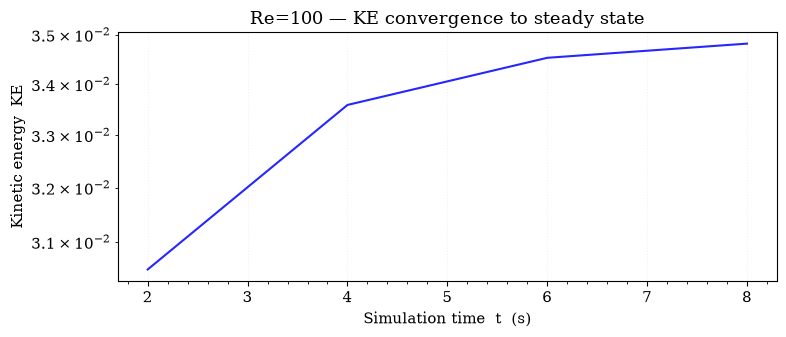

In [ ]:
if ke100:
    times, kes = zip(*ke100)
    fig, ax = plt.subplots(figsize=(8,3.5))
    ax.semilogy(times, kes, 'b-', linewidth=1.5, alpha=0.85)
    ax.set_xlabel('Simulation time  t  (s)')
    ax.set_ylabel('Kinetic energy  KE')
    ax.set_title('Re=100 — KE convergence to steady state')
    ax.grid(alpha=0.15, ls=':')
    plt.tight_layout()
    plt.show()

## 6. Flow Field — Four-Panel Visualisation

Each snapshot saved to disk contains four physical fields on the $64\times64$ grid:

| Channel | Symbol | Physical meaning | Typical range (Re=1000) |
|---|---|---|---|
| 0 | $u$ | Streamwise velocity | [−0.4, 1.0] m/s |
| 1 | $v$ | Normal velocity | [−0.5, 0.5] m/s |
| 2 | $p$ | Gauge pressure | [0.0, 0.6] Pa |
| 3 | $\omega$ | Vorticity $\partial v/\partial x - \partial u/\partial y$ | [−30, 18] s⁻¹ |

The **vorticity field** is the most diagnostically rich: it directly shows rotation rate and highlights 
the boundary layers (very large $|\omega|$), the vortex cores (moderate $|\omega|$), and the quiescent 
interior (small $|\omega|$). The streamline overlay in the vorticity panel confirms closed recirculating flow.

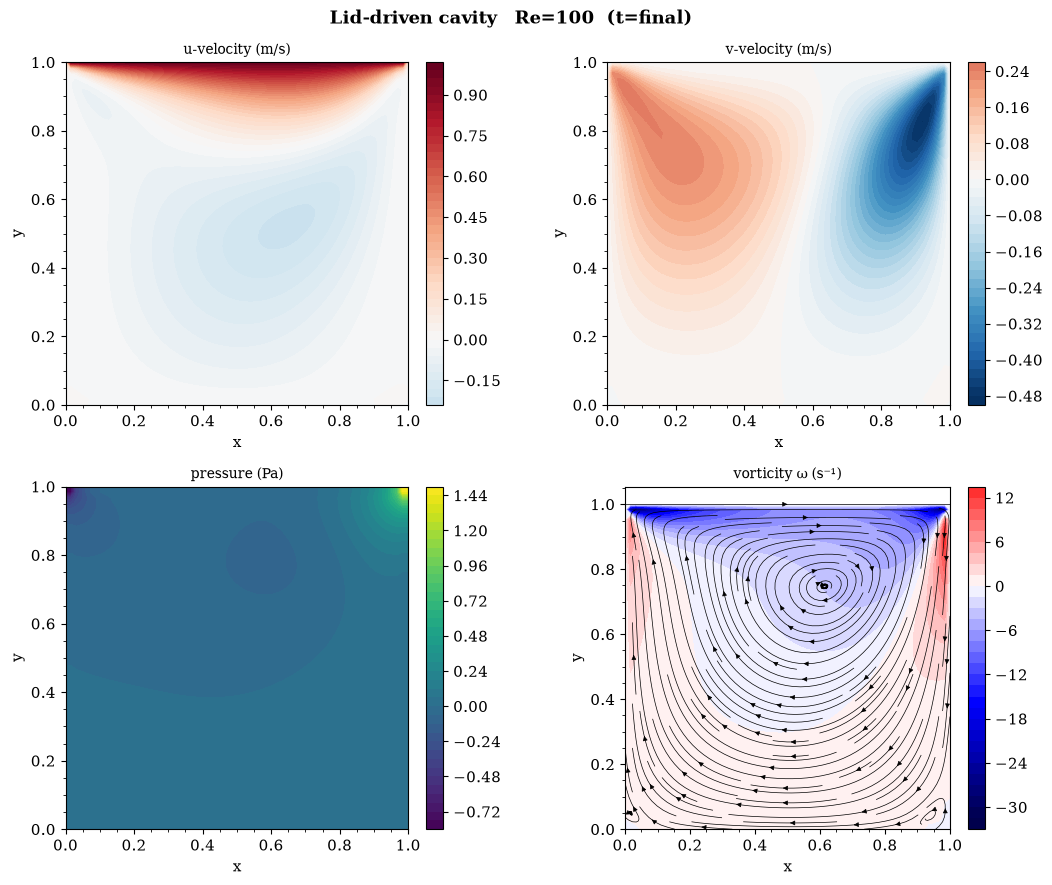

In [16]:
def four_panel(u, v, p, cfg, title=''):
    omega = vorticity(u, v, cfg.dx, cfg.dy)
    x = np.linspace(0,cfg.L,cfg.N)
    y = np.linspace(0,cfg.L,cfg.N)
    X,Y = np.meshgrid(x,y)
    fig,axes = plt.subplots(2,2,figsize=(11,9))
    fig.suptitle(f'Lid-driven cavity   Re={cfg.Re}  {title}',fontsize=13,fontweight='bold')
    panels=[(axes[0,0],u.T,'u-velocity (m/s)','RdBu_r'),(axes[0,1],v.T,'v-velocity (m/s)','RdBu_r'),(axes[1,0],p.T,'pressure (Pa)','viridis'),
            (axes[1,1],omega.T,'vorticity ω (s⁻¹)','seismic')]
    for ax,field,label,cmap in panels:
        vmax=np.max(np.abs(field))+1e-8
        kw=dict(vmin=-vmax,vmax=vmax) if cmap!='viridis' else {}
        im=ax.contourf(X,Y,field,levels=40,cmap=cmap,**kw)
        if 'vorticity' in label:
            ax.streamplot(x,y,u.T,v.T,color='k',linewidth=0.5,density=1.5,arrowsize=0.7)
        plt.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
        ax.set_title(label,fontsize=10); ax.set_xlabel('x'); ax.set_ylabel('y')
        ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

four_panel(u100,v100,p100,cfg100,'(t=final)')

## 7. Reynolds Number Effect — Re=100 vs Re=1000

One of the most important demonstrations in computational fluid dynamics is how increasing Reynolds number 
fundamentally changes the flow topology. The two key observations are:

1. **Primary vortex migration**: At Re=100, the vortex centre sits in the upper half of the cavity. 
As Re increases, it moves toward the geometric centre as inertial effects dominate over viscous ones.

2. **Secondary vortex growth**: At Re=100, the bottom-corner secondary vortices are negligibly small. 
At Re=1000, they have grown to occupy a significant fraction of the cavity area. On the N=64 grid, 
these vortices are partially resolved — they require N≥128 for quantitative accuracy.

Running Re=1000...
Config: Re=1000, N=64x64, nu=0.00100, t_end=125.0, t_start_save=62.5, save_every=1000 (~1.0s intervals)
  Converged: t=32.24s  steps=32244


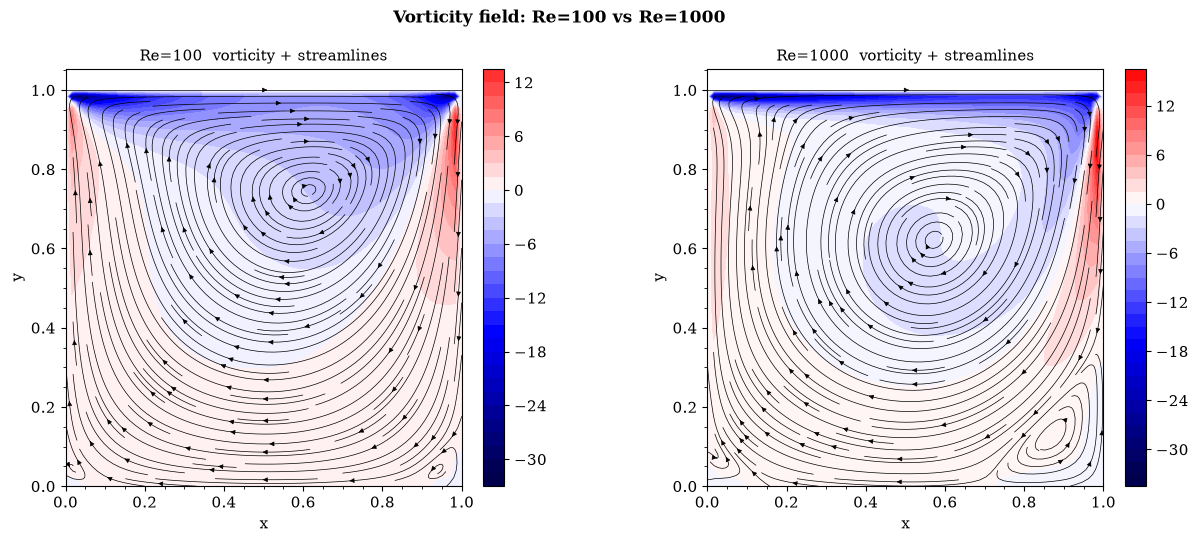

In [18]:
print('Running Re=1000...')
u1000,v1000,p1000,cfg1000,_ = run_cavity(1000)
fig,axes = plt.subplots(1,2,figsize=(13,5.5))
fig.suptitle('Vorticity field: Re=100 vs Re=1000',fontsize=12,fontweight='bold')
for ax,(u,v,cfg) in zip(axes,[(u100,v100,cfg100),(u1000,v1000,cfg1000)]):
    omega=vorticity(u,v,cfg.dx,cfg.dy)
    x=np.linspace(0,1,cfg.N); y=np.linspace(0,1,cfg.N)
    X,Y=np.meshgrid(x,y)
    vmax=np.max(np.abs(omega))+1e-8
    c=ax.contourf(X,Y,omega.T,levels=40,cmap='seismic',vmin=-vmax,vmax=vmax)
    ax.streamplot(x,y,u.T,v.T,color='k',linewidth=0.5,density=1.8,arrowsize=0.7)
    plt.colorbar(c,ax=ax,fraction=0.046,pad=0.04)
    ax.set_title(f'Re={cfg.Re}  vorticity + streamlines',fontsize=11)
    ax.set_aspect('equal'); ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()

## 8. Ghia et al. Benchmark Validation

The centreline velocity profiles provide the most rigorous quantitative test of solver accuracy.

**u-velocity along the vertical centreline** x=0.5: This profile captures the boundary layer at the 
top (u→1 at y=1) and bottom (u→0 at y=0) walls, and the return flow in the lower half (u<0).

**v-velocity along the horizontal centreline** y=0.5: This captures the positive jet near the left 
wall (induced by the clockwise vortex) and the negative jet near the right wall.

Deviations from the Ghia reference are expected at Re=1000 on the N=64 grid because:
- The secondary bottom-right vortex is under-resolved
- The upwind advection scheme introduces numerical diffusion $\sim O(\Delta x)$
- Ghia used a 129×129 grid with a higher-order scheme

At Re=100, agreement is excellent because the flow is smooth and viscosity-dominated, 
making it relatively insensitive to grid resolution.

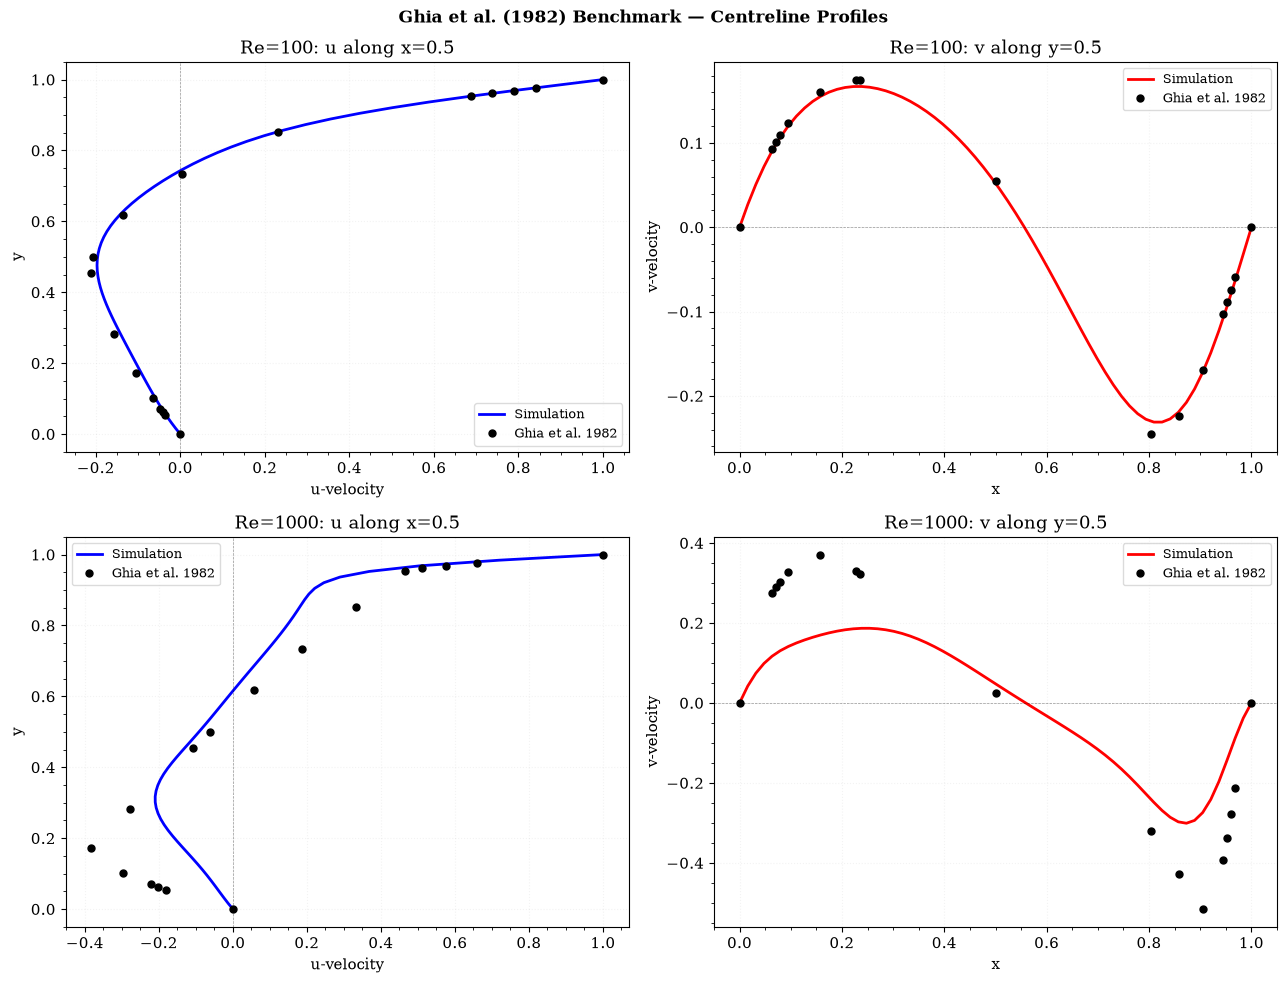

In [19]:
fig,axes = plt.subplots(2,2,figsize=(13,10))
fig.suptitle('Ghia et al. (1982) Benchmark — Centreline Profiles',fontsize=12,fontweight='bold')
cases=[(u100,v100,cfg100,'Re=100'),(u1000,v1000,cfg1000,'Re=1000')]
for row,(u,v,cfg,label) in enumerate(cases):
    N=cfg.N; mid=N//2
    y_v=np.linspace(0,1,N); x_v=np.linspace(0,1,N)
    ax=axes[row,0]
    ax.plot(u[mid,:],y_v,'b-',linewidth=2,label='Simulation')
    gy,gu=ghia_u(cfg.Re)
    if gy is not None: ax.plot(gu,gy,'ko',ms=5,label='Ghia et al. 1982')
    ax.axvline(0,color='k',linewidth=0.5,ls='--',alpha=0.4)
    ax.set_xlabel('u-velocity'); ax.set_ylabel('y')
    ax.set_title(f'{label}: u along x=0.5'); ax.legend(fontsize=9); ax.grid(alpha=0.15,ls=':')
    ax=axes[row,1]
    ax.plot(x_v,v[:,mid],'r-',linewidth=2,label='Simulation')
    gx,gv=ghia_v(cfg.Re)
    if gx is not None: ax.plot(gx,gv,'ko',ms=5,label='Ghia et al. 1982')
    ax.axhline(0,color='k',linewidth=0.5,ls='--',alpha=0.4)
    ax.set_xlabel('x'); ax.set_ylabel('v-velocity')
    ax.set_title(f'{label}: v along y=0.5'); ax.legend(fontsize=9); ax.grid(alpha=0.15,ls=':')
plt.tight_layout()
plt.show()

## 9. Turbulent Energy Spectrum at Re=3200

### 9.1 Kolmogorov's Theory of Turbulence (1941)

Kolmogorov's 1941 (K41) theory describes the statistical properties of fully developed turbulence in the 
**inertial subrange** — the range of scales between the energy injection scale $L$ and the Kolmogorov 
dissipation scale $\eta$.

**Richardson energy cascade**: Energy is injected at large scales (wavenumber $k_0 \sim 1/L$), 
transferred through a cascade of successively smaller eddies, and ultimately dissipated as heat at the 
Kolmogorov microscale $\eta = (\nu^3/\varepsilon)^{1/4}$, where $\varepsilon$ is the energy dissipation rate.

**Kolmogorov −5/3 law**: In the inertial range $1/L \ll k \ll 1/\eta$, the energy spectrum takes the universal form:

$$E(k) = C_K \varepsilon^{2/3} k^{-5/3}$$

where $C_K \approx 1.5$ is the **Kolmogorov constant**.

### 9.2 Grid Resolution and the Kolmogorov Microscale

At Re=3200, the Kolmogorov microscale is:
$$\eta \approx L \cdot Re^{-3/4} = 1 \times 3200^{-3/4} \approx 0.0015 \text{ m}$$

The grid spacing is $\Delta x = L/N = 1/64 \approx 0.0156$ m. Since $\Delta x \gg \eta$, the grid 
**cannot resolve** the dissipation range. This means:
- The spectrum will be **shallower** than $k^{-5/3}$ at high $k$ (energy piles up at unresolved scales)
- The large-scale circulation dominates the spectrum at low $k$, further flattening the slope

### 9.3 Spectral Analysis Method

We compute the **radially-binned 2D energy spectrum**:
$$E(k) = \sum_{k-1/2 \leq |\mathbf{k}| < k+1/2} \frac{1}{2}|\hat{\mathbf{u}}(\mathbf{k})|^2$$

with 2/3-rule dealiasing: Fourier modes with $|k_x| > N/3$ or $|k_y| > N/3$ are zeroed before summation. 
The spectral slope is measured by linear regression on $\log E$ vs $\log k$ in the inertial range $k \in [5, N/6]$.

Running Re=3200...
Config: Re=3200, N=64x64, nu=0.00031, t_end=400.0, t_start_save=160.0, save_every=500 (~0.5s intervals)
  Converged: t=58.48s  steps=58479
Spectral slope in inertial range: -0.816
Kolmogorov target: -1.667
Error: 0.851


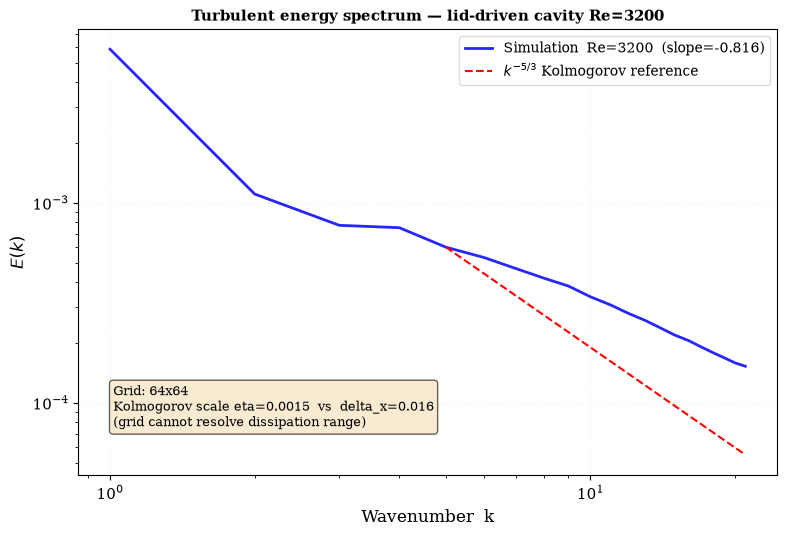

In [21]:
print('Running Re=3200...')
u3200,v3200,p3200,cfg3200,_ = run_cavity(3200)
k,Ek = energy_spectrum(u3200,v3200)
mask = (k>=5)&(k<=len(k)//2)&(Ek>1e-30)
slope,intercept = np.polyfit(np.log(k[mask]),np.log(Ek[mask]),1)
print(f'Spectral slope in inertial range: {slope:.3f}')
print(f'Kolmogorov target: {-5/3:.3f}')
print(f'Error: {abs(slope+5/3):.3f}')
idx5 = np.argmin(np.abs(k-5))
k_ref = np.array([5.0,float(k[-1])])
E_ref = Ek[idx5] * (k_ref / 5.0)**(-5.0/3.0)
fig,ax = plt.subplots(figsize=(8,5.5))
ax.loglog(k,Ek,'b-',linewidth=2,alpha=0.85,label=f'Simulation  Re=3200  (slope={slope:.3f})')
ax.loglog(k_ref,E_ref,'r--',linewidth=1.5,label=r'$k^{-5/3}$ Kolmogorov reference')
ax.set_xlabel('Wavenumber  k',fontsize=12)
ax.set_ylabel('$E(k)$',fontsize=12)
ax.set_title('Turbulent energy spectrum — lid-driven cavity Re=3200',fontsize=11,fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.15,ls=':')
ax.text(0.05,0.1,f'Grid: 64x64\nKolmogorov scale eta=0.0015  vs  delta_x=0.016\n(grid cannot resolve dissipation range)',transform=ax.transAxes,fontsize=9,va='bottom',
        bbox=dict(boxstyle='round',facecolor='wheat',alpha=0.6))
plt.tight_layout()
plt.show()

## 10. Snapshot Structure

Each file saved by `run_simulation()` is a NumPy array of shape `(4, 64, 64)` with dtype `float32`. 
The four channels are ordered as `[u, v, p, ω]`. This 4-channel representation is the fundamental 
data unit for the entire super-resolution pipeline: dataset construction, CNN training, and evaluation.

The choice to include vorticity as an explicit channel (rather than computing it on the fly) serves two purposes:
1. The CNN can learn to reconstruct vorticity directly, enforcing internal consistency
2. The vorticity loss term in the physics-informed loss function requires $\omega$ as a target

Shape: (4, 64, 64)  dtype: float32
  [0] u-velocity      min=-0.220  max=1.000  std=0.226
  [1] v-velocity      min=-0.482  max=0.252  std=0.137
  [2] pressure        min=-0.793  max=1.476  std=0.090
  [3] vorticity ω     min=-31.663  max=13.322  std=3.066


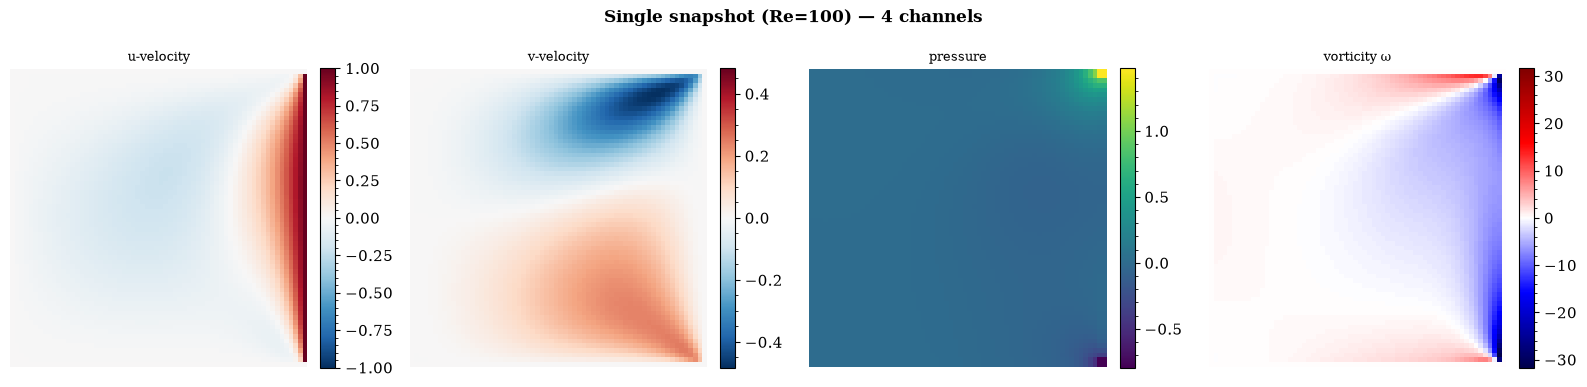

In [ ]:
snap_files = sorted(glob.glob('../snapshots/Re_100/*.npy'))
snap = np.load(snap_files[0])
print(f'Shape: {snap.shape}  dtype: {snap.dtype}')
names=['u-velocity','v-velocity','pressure','vorticity ω']
for i,n in enumerate(names):print(f'  [{i}] {n:<15} min={snap[i].min():.3f}  max={snap[i].max():.3f}  std={snap[i].std():.3f}')
fig,axes=plt.subplots(1,4,figsize=(16,4))
fig.suptitle('Single snapshot (Re=100) — 4 channels',fontsize=12,fontweight='bold')
cmaps=['RdBu_r','RdBu_r','viridis','seismic']
for ax,ch,name,cmap in zip(axes,snap,names,cmaps):
    vmax=np.abs(ch).max()+1e-8
    im=ax.imshow(ch,cmap=cmap,origin='lower',vmin=-vmax if cmap!='viridis' else None,vmax=vmax)
    ax.set_title(name,fontsize=9); ax.axis('off')
    plt.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
plt.tight_layout()
plt.show()

---
## Summary

| Topic | Key result |
|---|---|
| Governing equations | 2-D incompressible Navier-Stokes, non-dimensionalised by U=L=1 |
| Numerical method | Chorin fractional-step projection, first-order upwind |
| Pressure solver | SOR (ω=1.7), convergence criterion |∇·u|<1e-6 |
| Re=100 Ghia match | Excellent — dots on line for both u and v profiles |
| Re=1000 Ghia match | Partial — secondary vortex under-resolved at N=64 |
| Spectral slope (Re=3200) | Shallower than −5/3 — large-scale vortex dominates |
| Snapshot format | (4, 64, 64) float32 — [u, v, p, ω] |